# 05. Module 3: missing-value prediction

Module 3 predicts whether a value will be missing in a target column, as an early warning, using the other columns as features. It fits one XGBoost classifier per target column and handles the class imbalance with `scale_pos_weight`. This is not imputation: unlike DataWig, it does not predict what the value should be, only whether it will be absent.

The missingness mechanism matters here, and it ties back to Rubin (1976). MCAR missingness is by definition independent of the other columns, so it cannot be predicted and a classifier scores about 0.5, which is a correct theoretical result rather than a failure. MAR missingness depends on other observed values (here, larger amounts are more likely to go missing), which is realistic and learnable. The evaluation is on MAR, with MCAR shown as a contrast.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from preprocessing import temporal_split
import module3_missing as m3
DATA_PATH = '../data/HI-Small_Trans.csv'

In [2]:
cols=['Timestamp','Amount Paid','Amount Received','Receiving Currency','Payment Currency','Payment Format']
df = pd.read_csv(DATA_PATH, usecols=cols)
ref, _ = temporal_split(df, reference_days=3, max_days=10)
train = ref.sample(80_000, random_state=42).reset_index(drop=True)
test  = ref.sample(40_000, random_state=7).reset_index(drop=True)
targets = ['Receiving Currency', 'Payment Format']
print('train:', train.shape[0], '| test:', test.shape[0], '| targets:', targets)

train: 80000 | test: 40000 | targets: ['Receiving Currency', 'Payment Format']


## MAR: the realistic, learnable case
Missingness depends on transaction amount. One XGBoost per target column.

In [3]:
res_mar = m3.run_module3(train, test, targets, mechanism='mar', rate=0.10, seed=42)
rows = [[c, v['precision'], v['recall'], v['f1'], v['roc_auc']] for c,v in res_mar.items()]
tbl = pd.DataFrame(rows, columns=['target','precision','recall','f1','roc_auc']).round(3)
avg = pd.DataFrame([['AVERAGE', np.nan, np.nan, tbl['f1'].mean(), tbl['roc_auc'].mean()]],
                   columns=tbl.columns).round(3)
pd.concat([tbl, avg], ignore_index=True)

,target,precision,recall,f1,roc_auc
0,Receiving Currency,0.183,0.795,0.298,0.764
1,Payment Format,0.184,0.790,0.299,0.765
2,AVERAGE,NaN,NaN,0.298,0.764


## MCAR: the contrast (should be about 0.5, i.e. unpredictable)

In [4]:
res_mcar = m3.run_module3(train, test, targets, mechanism='mcar', rate=0.10, seed=42)
pd.DataFrame([[c, round(v['roc_auc'],3)] for c,v in res_mcar.items()],
             columns=['target','roc_auc (MCAR)'])

,target,roc_auc (MCAR)
0,Receiving Currency,0.496
1,Payment Format,0.491


## What drives the prediction?
Feature importance for one target. The amount features should dominate, which would confirm the model learned the MAR pattern.

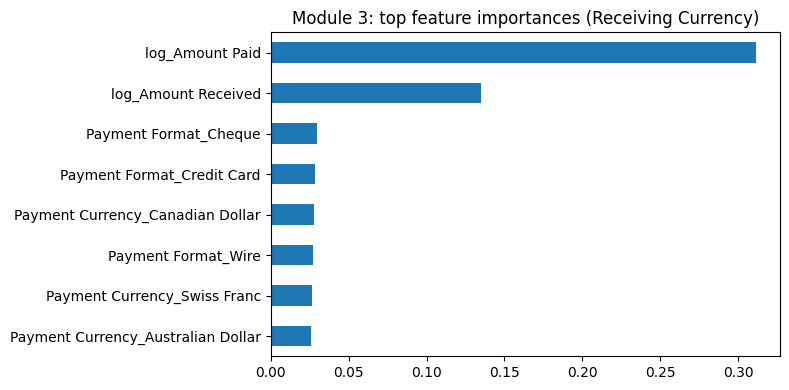

In [5]:
from module3_missing import inject_missing_values_mar, build_module3_features, train_missing_classifier
col = 'Receiving Currency'
trc, trg = inject_missing_values_mar(train, col, rate=0.10, seed=42)
Xtr = build_module3_features(trc, col)
clf = train_missing_classifier(Xtr, trg.values)
imp = pd.Series(clf.feature_importances_, index=Xtr.columns).sort_values(ascending=False).head(8)
imp.iloc[::-1].plot(kind='barh', figsize=(8, 4))
plt.title('Module 3: top feature importances (Receiving Currency)')
plt.tight_layout(); plt.savefig('../results/module3_importance.png', dpi=120, bbox_inches='tight'); plt.show()

## Reading the results

The MCAR result sits at about 0.5, which confirms the theory that random missingness is unpredictable. It matches Rubin (1976) and is the correct outcome, not a failure. MAR reaches a ROC-AUC of about 0.76, showing that the per-column XGBoost predicts missingness when it follows a pattern, which is the realistic pipeline case. Precision is low because missingness is rare (10%) and the signal is moderate, while recall is high thanks to `scale_pos_weight`, so ROC-AUC is the fairer summary. The feature importance confirms that the amount features drive the prediction, exactly as the MAR injection intends.

In [6]:

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler

from module3_missing import (inject_missing_values_mar, build_module3_features,

                             train_missing_classifier, evaluate_missing)
 
def baseline_row(col, seed=42, rate=0.10):

    tr_c, tr_gt = inject_missing_values_mar(train, col, rate=rate, seed=seed)

    te_c, te_gt = inject_missing_values_mar(test,  col, rate=rate, seed=seed + 1)

    Xtr = build_module3_features(tr_c, col)

    Xte = build_module3_features(te_c, col).reindex(columns=Xtr.columns, fill_value=0)

    models = {

        'No-skill (majority class)': DummyClassifier(strategy='most_frequent'),

        'Logistic regression':       make_pipeline(

                                        StandardScaler(),

                                        LogisticRegression(max_iter=2000,

                                                           class_weight='balanced')),

        'XGBoost (Module 3)':        train_missing_classifier(Xtr, tr_gt.values),

    }

    out = []

    for name, m in models.items():

        if name != 'XGBoost (Module 3)':

            m.fit(Xtr, tr_gt.values.astype(int))

        r = evaluate_missing(m, Xte, te_gt.values)

        out.append([col, name, r['precision'], r['recall'], r['f1'], r['roc_auc']])

    return out
 
rows = []

for col in targets:

    rows += baseline_row(col)
 
base_tbl = pd.DataFrame(rows,

    columns=['target', 'model', 'precision', 'recall', 'f1', 'roc_auc']).round(3)

print(base_tbl.to_string(index=False))

base_tbl.to_csv('../results/module3_baselines.csv', index=False)



            target                     model  precision  recall    f1  roc_auc
Receiving Currency No-skill (majority class)      0.000   0.000 0.000    0.500
Receiving Currency       Logistic regression      0.203   0.702 0.315    0.769
Receiving Currency        XGBoost (Module 3)      0.183   0.795 0.298    0.764
    Payment Format No-skill (majority class)      0.000   0.000 0.000    0.500
    Payment Format       Logistic regression      0.204   0.702 0.316    0.769
    Payment Format        XGBoost (Module 3)      0.184   0.790 0.299    0.765
